# Gamma Distribution Cumulative Growth Model for YouTube Viewership Forecasting

This notebook implements a Gamma Distribution Cumulative Growth Model for video viewership forecasting.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gamma
from scipy.optimize import curve_fit
from sklearn.metrics import median_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set consistent styling
sns.set_style("darkgrid")

# Set random seed for reproducibility
np.random.seed(42)

print("Imports and styling setup complete.")

Imports and styling setup complete.


## 1. DATA LOADING AND CLEANING

- Load all three CSVs
- Convert counts to numeric
- Convert ALL datetime columns enforcing UTC
- Merge timeseries with videos_rows
- Compute hours_since_publish
- Drop invalid rows

In [3]:
print("Loading CSV datasets...")
channel_stats = pd.read_csv('/content/drive/Othercomputers/My Laptop/models/channel_stats_updated.csv')
videos_rows = pd.read_csv('/content/drive/Othercomputers/My Laptop/models/videos_rows_updated.csv')
view_timeseries = pd.read_csv('/content/drive/Othercomputers/My Laptop/models/view_timeseries.csv')

for col in ['view_count', 'like_count', 'comment_count']:
    view_timeseries[col] = pd.to_numeric(view_timeseries[col], errors='coerce')

for df, cols in [(channel_stats, ['processed_at', 'created_at']),
                 (videos_rows, ['published_at', 'last_polled_at', 'next_poll_at', 'created_at']),
                 (view_timeseries, ['scraped_at'])]:
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce', utc=True)

print("\nMerging view_timeseries with videos_rows on video_id...")
merged = view_timeseries.merge(videos_rows[['video_id', 'published_at', 'channel_id']], on='video_id', how='left')

merged['hours_since_publish'] = (merged['scraped_at'] - merged['published_at']).dt.total_seconds() / 3600.0

cnt_initial = len(merged)
print(f"Initial row count: {cnt_initial}")

merged_a = merged.dropna(subset=['view_count'])
cnt_a = len(merged_a)
print(f"Filter a: Drop null view_count. Remaining: {cnt_a} (dropped {cnt_initial - cnt_a} rows)")

merged_b = merged_a.dropna(subset=['hours_since_publish'])
cnt_b = len(merged_b)
print(f"Filter b: Drop null hours_since_publish. Remaining: {cnt_b} (dropped {cnt_a - cnt_b} rows)")

merged_c = merged_b[merged_b['hours_since_publish'] > 0]
cnt_c = len(merged_c)
print(f"Filter c: Drop hours_since_publish <= 0. Remaining: {cnt_c} (dropped {cnt_b - cnt_c} rows)")

merged_d = merged_c[merged_c['view_count'] >= 0]
cnt_d = len(merged_d)
print(f"Filter d: Drop view_count < 0. Remaining: {cnt_d} (dropped {cnt_c - cnt_d} rows)")

cleaned_ts = merged_d.sort_values(by=['video_id', 'hours_since_publish']).reset_index(drop=True)

print("\nFinal cleaned dataframe info:")
print(cleaned_ts.dtypes)
print("\nNull counts in cleaned dataframe:")
print(cleaned_ts.isnull().sum())

Loading CSV datasets...

Merging view_timeseries with videos_rows on video_id...
Initial row count: 1136714
Filter a: Drop null view_count. Remaining: 1136703 (dropped 11 rows)
Filter b: Drop null hours_since_publish. Remaining: 1136703 (dropped 0 rows)
Filter c: Drop hours_since_publish <= 0. Remaining: 1135214 (dropped 1489 rows)
Filter d: Drop view_count < 0. Remaining: 1135214 (dropped 0 rows)

Final cleaned dataframe info:
id                                  object
video_id                            object
scraped_at             datetime64[ns, UTC]
view_count                         float64
like_count                         float64
comment_count                      float64
published_at           datetime64[ns, UTC]
channel_id                          object
hours_since_publish                float64
dtype: object

Null counts in cleaned dataframe:
id                     0
video_id               0
scraped_at             0
view_count             0
like_count             0
comment

## 2. VIDEO ELIGIBILITY FILTERING AND LEAKAGE-FREE TRAIN/TEST SPLIT

**CRITICAL — NO DATA LEAKAGE**: The split is strictly by TIME per video. No future scrape point ever influences model fitting.

In [4]:
TRAIN_CUTOFF_HOURS = 120    # 5 days — only scrapes before this are used for fitting
FORECAST_HORIZON_HOURS = 168  # 7 days — prediction target
MIN_TRAIN_POINTS = 5         # minimum scrape points in training window to attempt a fit

video_groups = cleaned_ts.groupby('video_id')

eligible_videos = []
train_points_counts = []
train_hours_ranges = []
target_hours_list = []
target_views_list = []

total_videos = len(video_groups)
dropped_insufficient_train = 0
dropped_no_target = 0

for video_id, group in video_groups:
    # LEAKAGE GUARD: Strictly filtering data before TRAIN_CUTOFF_HOURS
    train_data = group[group['hours_since_publish'] < TRAIN_CUTOFF_HOURS]

    # Target points evaluated independently
    target_candidates = group[group['hours_since_publish'] >= FORECAST_HORIZON_HOURS]

    if len(train_data) < MIN_TRAIN_POINTS:
        dropped_insufficient_train += 1
        continue

    if len(target_candidates) == 0:
        dropped_no_target += 1
        continue

    target_idx = (target_candidates['hours_since_publish'] - FORECAST_HORIZON_HOURS).abs().idxmin()
    target_row = target_candidates.loc[target_idx]

    eligible_videos.append(video_id)
    train_points_counts.append(len(train_data))
    train_hours_ranges.append((train_data['hours_since_publish'].min(), train_data['hours_since_publish'].max()))
    target_hours_list.append(target_row['hours_since_publish'])
    target_views_list.append(target_row['view_count'])

print(f"Total videos before filtering: {total_videos}")
print(f"Videos dropped for insufficient train points: {dropped_insufficient_train}")
print(f"Videos dropped for no target point: {dropped_no_target}")
print(f"Final eligible video count: {len(eligible_videos)}")

print("\nExample eligible videos:")
example_df = pd.DataFrame({
    'video_id': eligible_videos[:5],
    'train_points': train_points_counts[:5],
    'train_hours_range': train_hours_ranges[:5],
    'target_hours': target_hours_list[:5],
    'target_view_count': target_views_list[:5]
})
print(example_df)

Total videos before filtering: 7012
Videos dropped for insufficient train points: 4013
Videos dropped for no target point: 1957
Final eligible video count: 1042

Example eligible videos:
      video_id  train_points                         train_hours_range  \
0  -9heRLrZJaY            75   (38.11238948083333, 119.08700398916666)   
1  -BwMuXyuK1w            52   (60.61377836972222, 119.83997151055556)   
2  -S2AbW0e6kc           105   (5.047386604722223, 119.29743066166667)   
3  -TGuFEtHJTc           107          (1.10434886, 119.18258241277778)   
4  -YHGg6YMmUE           117  (0.6516635152777778, 119.50542669305555)   

   target_hours  target_view_count  
0    168.507059               59.0  
1    169.006060               85.0  
2    168.213930              217.0  
3    168.017523              495.0  
4    168.318119            12799.0  


## 3. GAMMA CUMULATIVE GROWTH MODEL — EXPLANATION

The model treats video views over time as following a saturation curve with three phases:
- Early phase: fast initial growth from subscribers and shares
- Mid phase: organic discovery via recommendations
- Late phase: tapering toward a maximum ceiling

The model equation is:
  V(t) = M * GammaCDF(t; k, lambda)

Where:
  - V(t) = cumulative views at time t (hours since publish)
  - M = market ceiling — maximum total views the video will ever reach
  - k = shape parameter — controls how sharply the curve accelerates (high k = sharp viral burst, low k = slow burn)
  - lambda = rate parameter — controls how fast the video reaches peak activity
  - GammaCDF = scipy.stats.gamma.cdf(t, a=k, scale=1/lambda)

Parameter intuition:
  - High M + high k + high lambda = viral video with fast sharp spike and high ceiling
  - High M + low k + low lambda = slow-burn video that keeps growing steadily
  - Low M = niche video with limited reach regardless of shape

scipy.optimize.curve_fit is used to find the M, k, lambda values that best fit the observed (hours, views) training data for each video.

Note:
  - This is extrapolation (predicting beyond observed data), not interpolation
  - Fitting is done ONLY on training window data (before TRAIN_CUTOFF_HOURS)
  - Evaluation is done on the held-out target point (at FORECAST_HORIZON_HOURS)
  - This prevents data leakage

In [5]:
def gamma_growth(t, M, k, lam):
    from scipy.stats import gamma
    return M * gamma.cdf(t, a=k, scale=1/lam)

results = []

print("Starting model fitting...")
for i, video_id in enumerate(eligible_videos):
    group = cleaned_ts[cleaned_ts['video_id'] == video_id]

    # LEAKAGE GUARD: Only use data before train cutoff for training
    train_data = group[group['hours_since_publish'] < TRAIN_CUTOFF_HOURS]
    target_candidates = group[group['hours_since_publish'] >= FORECAST_HORIZON_HOURS]

    t = train_data['hours_since_publish'].values
    V = train_data['view_count'].values

    target_idx = (target_candidates['hours_since_publish'] - FORECAST_HORIZON_HOURS).abs().idxmin()
    actual_views = target_candidates.loc[target_idx, 'view_count']

    # Normalize t
    t_norm = t / TRAIN_CUTOFF_HOURS

    M_init = max(V) * 3 if len(V) > 0 and max(V) > 0 else 1000
    k_init = 2.0
    lam_init = 1.0

    M_min = max(V) if len(V) > 0 else 1
    M_max = max(V) * 1000 if len(V) > 0 and max(V) > 0 else 1e9

    fit_status = "ok"
    M, k, lam = np.nan, np.nan, np.nan
    predicted_views = np.nan

    try:
        popt, _ = curve_fit(
            gamma_growth, t_norm, V,
            p0=[M_init, k_init, lam_init],
            bounds=([M_min, 0.1, 0.001], [M_max, 50, 100]),
            maxfev=10000
        )
        M, k, lam = popt

        # Predict at forecast horizon
        t_target_norm = FORECAST_HORIZON_HOURS / TRAIN_CUTOFF_HOURS
        predicted_views = gamma_growth(t_target_norm, M, k, lam)

        if pd.isna(predicted_views) or np.isinf(predicted_views) or predicted_views > 1e9 or predicted_views < 0:
            fit_status = "prediction_clipped"
            predicted_views = np.clip(np.nan_to_num(predicted_views), 1, 5e8)

    except (RuntimeError, ValueError) as e:
        fit_status = "fit_failed"

    results.append({
        'video_id': video_id,
        'M': M,
        'k': k,
        'lam': lam,
        'predicted_views': predicted_views,
        'actual_views': actual_views,
        'n_train_points': len(t),
        'train_hours_max': t.max() if len(t) > 0 else 0,
        'fit_status': fit_status
    })

    if (i + 1) % 200 == 0:
        print(f"Fitted {i + 1} of {len(eligible_videos)} videos...")

results_df = pd.DataFrame(results)

print("\nFitting Complete!")
print(f"Total videos attempted: {len(eligible_videos)}")
ok_fits = sum(results_df['fit_status'] == 'ok')
print(f"Successful fits: {ok_fits}")
clipped_fits = sum(results_df['fit_status'] == 'prediction_clipped')
print(f"Clipped predictions count: {clipped_fits}")
failed_fits = sum(results_df['fit_status'] == 'fit_failed')
print(f"Failed fits (RuntimeError/ValueError): {failed_fits}")

results_df = results_df[results_df['fit_status'].isin(["ok", "prediction_clipped"])].copy()

Starting model fitting...
Fitted 200 of 1042 videos...
Fitted 400 of 1042 videos...
Fitted 600 of 1042 videos...
Fitted 800 of 1042 videos...
Fitted 1000 of 1042 videos...

Fitting Complete!
Total videos attempted: 1042
Successful fits: 1041
Clipped predictions count: 0
Failed fits (RuntimeError/ValueError): 1


## 5. PARAMETER ANALYSIS

                  M            k          lam
count  1.041000e+03  1041.000000  1041.000000
mean   6.480310e+06     1.522832    13.168782
std    1.691534e+08     3.797597    19.099983
min    3.000000e+00     0.100000     0.001000
25%    4.800000e+02     0.326491     2.263551
50%    2.206000e+03     0.677006     5.517246
75%    1.540443e+04     1.223064    15.561278
max    5.396301e+09    46.143250   100.000000


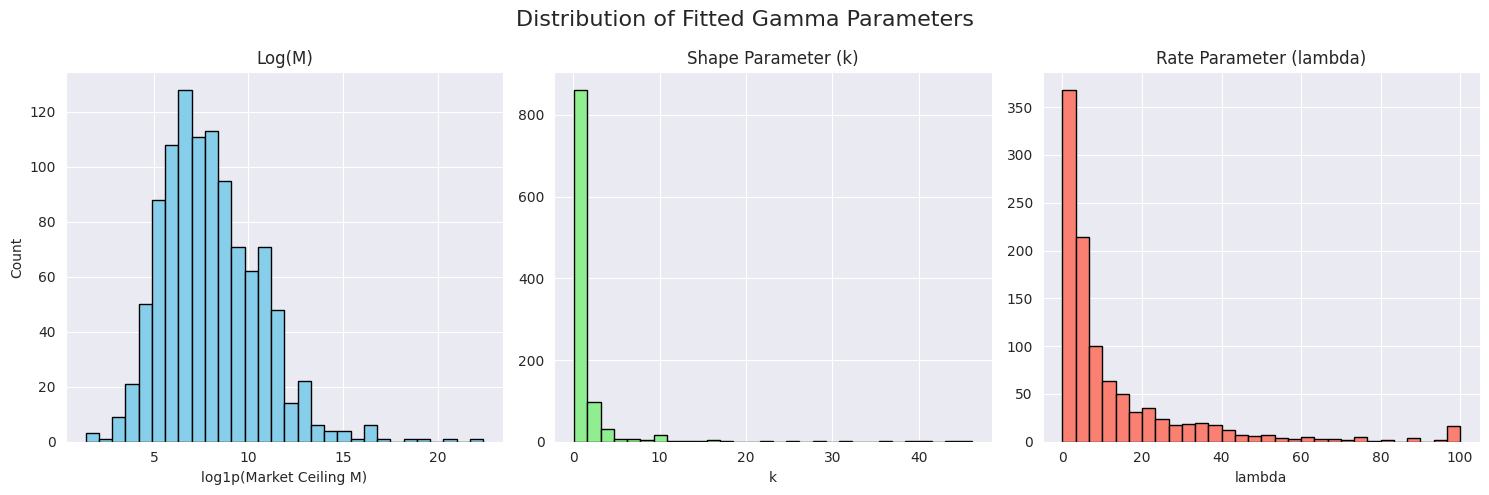

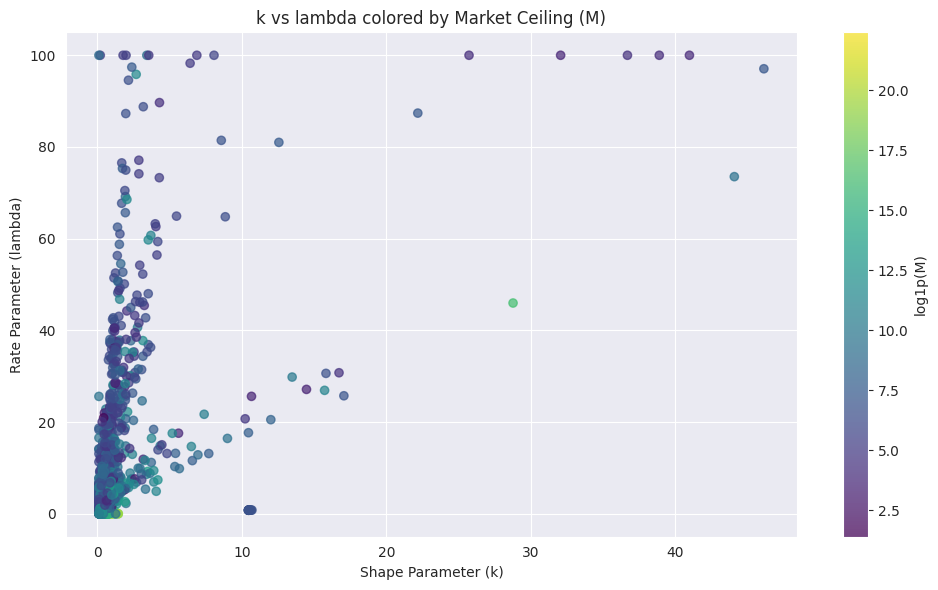


Flagged viral videos (k > 10th pct, lam > 10th pct, M > 75th pct): 174


In [6]:
print(results_df[['M', 'k', 'lam']].describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Distribution of Fitted Gamma Parameters", fontsize=16)

axes[0].hist(np.log1p(results_df['M']), bins=30, color='skyblue', edgecolor='black')
axes[0].set_title("Log(M)")
axes[0].set_xlabel("log1p(Market Ceiling M)")
axes[0].set_ylabel("Count")

axes[1].hist(results_df['k'], bins=30, color='lightgreen', edgecolor='black')
axes[1].set_title("Shape Parameter (k)")
axes[1].set_xlabel("k")

axes[2].hist(results_df['lam'], bins=30, color='salmon', edgecolor='black')
axes[2].set_title("Rate Parameter (lambda)")
axes[2].set_xlabel("lambda")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sc = plt.scatter(results_df['k'], results_df['lam'], c=np.log1p(results_df['M']), cmap='viridis', alpha=0.7)
plt.colorbar(sc, label='log1p(M)')
plt.title("k vs lambda colored by Market Ceiling (M)")
plt.xlabel("Shape Parameter (k)")
plt.ylabel("Rate Parameter (lambda)")
plt.grid(True)
plt.tight_layout()
plt.show()

k_10 = np.percentile(results_df['k'].dropna(), 10)
lam_10 = np.percentile(results_df['lam'].dropna(), 10)
M_75 = np.percentile(results_df['M'].dropna(), 75)

viral_mask = (results_df['k'] > k_10) & (results_df['lam'] > lam_10) & (results_df['M'] > M_75)
results_df['is_viral'] = viral_mask
print(f"\nFlagged viral videos (k > 10th pct, lam > 10th pct, M > 75th pct): {viral_mask.sum()}")

### Parameter Analysis Interpretation

The histograms reveal the general distributions of the fitted parameters for the Sri Lankan YouTube ecosystem:
- **Log(M)**: Shows the distribution of the estimated market ceiling. A wide range of values indicates both highly niche videos (low M) and potential viral hits (high M).
- **Shape (k)** and **Rate (lambda)**: Typically, these will show a skew. High concentration of low $k$ and $\lambda$ means a lot of videos follow a slow-burn trajectory.

The scatter plot colored by $M$ visualizes how the shape and rate relate to the video's ceiling. If the highest $M$ values cluster in the high $k$, high $\lambda$ quadrant, it strongly supports the hypothesis that sharp, fast acceleration leads to higher overall reach.

## 6. EVALUATION METRICS

Metrics interpretation:
- **MAE / RMSE (log scale)**: Measures typical prediction error magnitude, penalizing large proportional errors rather than large absolute views differences.
- **MAE / Median AE (views scale)**: Gives the error in actual view count terms. Median AE is robust to massive outlier misses.
- **MAPE**: The mean absolute percentage error across videos. Shows the average % miss.
- **Within Factor 2**: The percentage of videos where the prediction is between 50% and 200% of the true value. This is a crucial metric for business usability, representing "directionally correct" forecasts.
- **R2 Score (log scale)**: Variance explained by the model compared to predicting the mean. Higher is better (max 1.0).

In [7]:
valid_results = results_df.dropna(subset=['predicted_views', 'actual_views']).copy()

log_actual = np.log1p(valid_results['actual_views'])
log_pred = np.log1p(valid_results['predicted_views'])

log_mae = np.mean(np.abs(log_actual - log_pred))
log_rmse = np.sqrt(np.mean((log_actual - log_pred)**2))

views_mae = np.mean(np.abs(valid_results['actual_views'] - valid_results['predicted_views']))
views_medae = median_absolute_error(valid_results['actual_views'], valid_results['predicted_views'])

non_zero_actual = valid_results[valid_results['actual_views'] > 0]
excluded_mape = len(valid_results) - len(non_zero_actual)
mape = np.mean(np.abs((non_zero_actual['actual_views'] - non_zero_actual['predicted_views']) / non_zero_actual['actual_views']))

ratio = valid_results['predicted_views'] / valid_results['actual_views'].replace(0, np.nan)
factor_2 = ((ratio >= 0.5) & (ratio <= 2.0)).mean() * 100

r2 = r2_score(log_actual, log_pred)

metrics = {
    'Metric': [
        'MAE (log scale)', 'RMSE (log scale)',
        'MAE (views scale)', 'Median AE (views scale)',
        'MAPE', 'Within Factor 2 (%)', 'R2 Score (log scale)'
    ],
    'Gamma Model': [
        log_mae, log_rmse, views_mae, views_medae, mape, factor_2, r2
    ],
    'Power Law Baseline': [
        'TBD', 'TBD', 'TBD', 'TBD', 'TBD', 'TBD', 'TBD'
    ]
}
metrics_df = pd.DataFrame(metrics)
print(f"Excluded from MAPE (actual=0): {excluded_mape}")
display(metrics_df)

Excluded from MAPE (actual=0): 13


,Metric,Gamma Model,Power Law Baseline
0,MAE (log scale),0.031668,TBD
1,RMSE (log scale),0.069924,TBD
2,MAE (views scale),3725.422936,TBD
3,Median AE (views scale),18.863423,TBD
4,MAPE,0.031385,TBD
5,Within Factor 2 (%),98.559078,TBD
6,R2 Score (log scale),0.999182,TBD


## 7. DIAGNOSTIC PLOTS

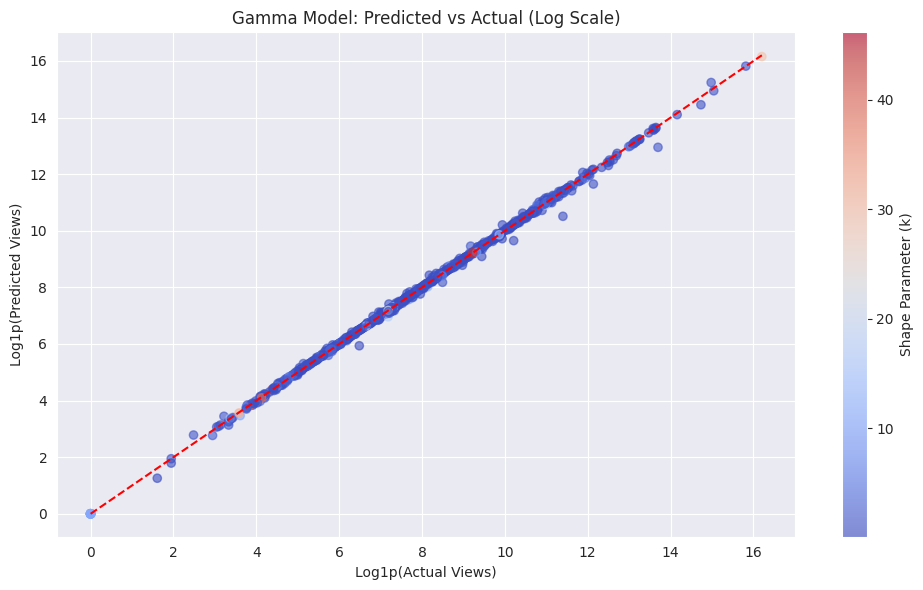

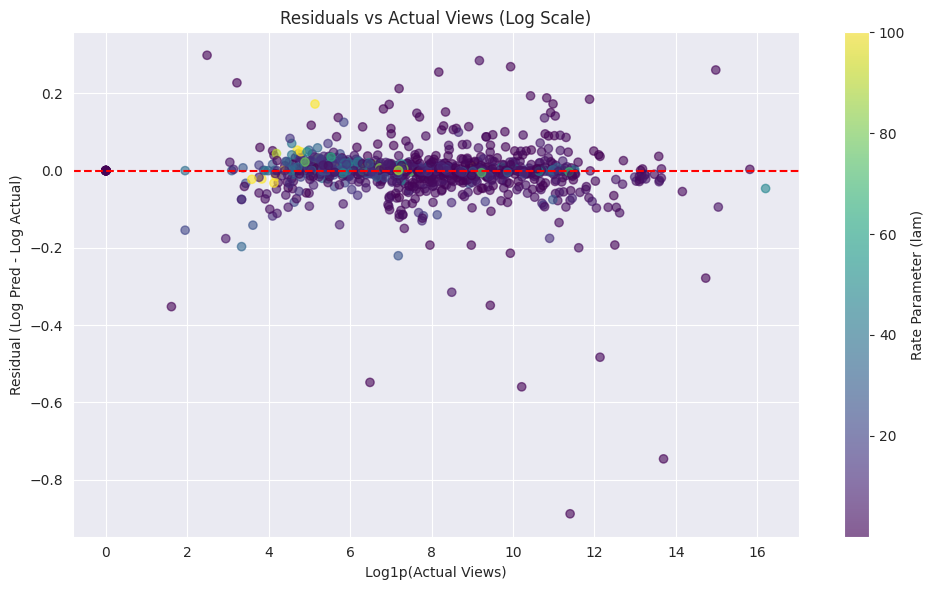

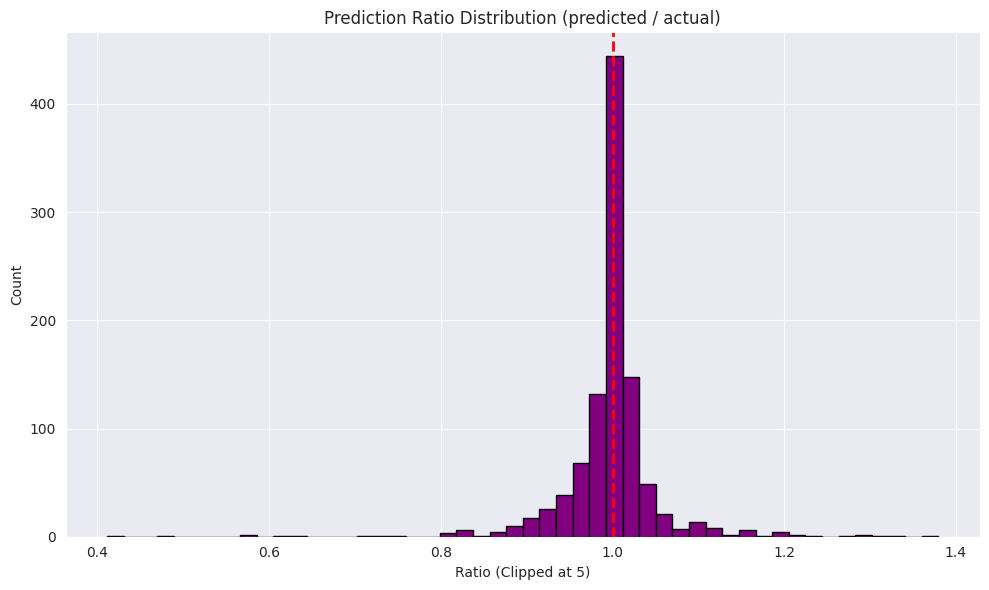

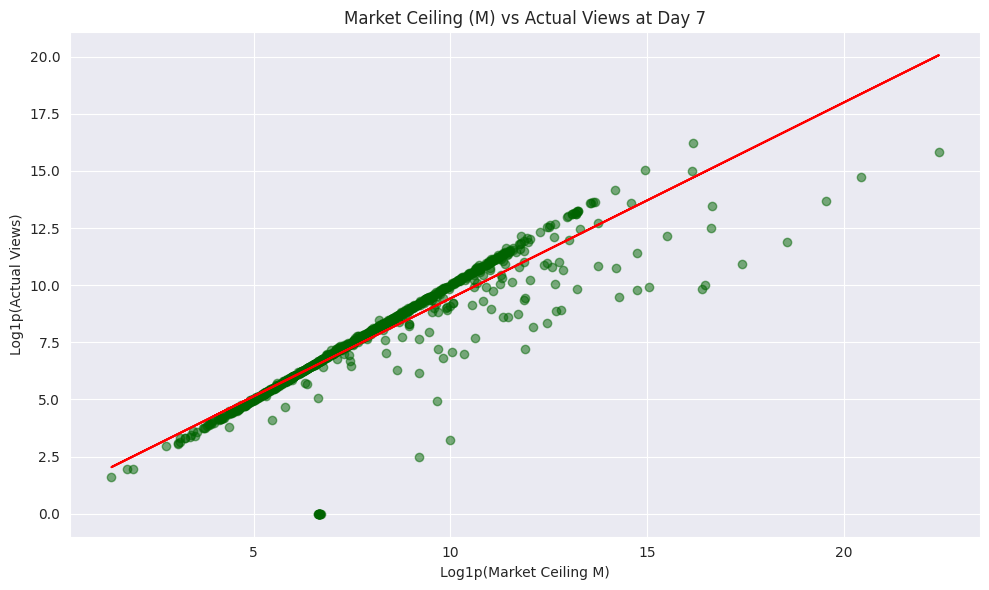

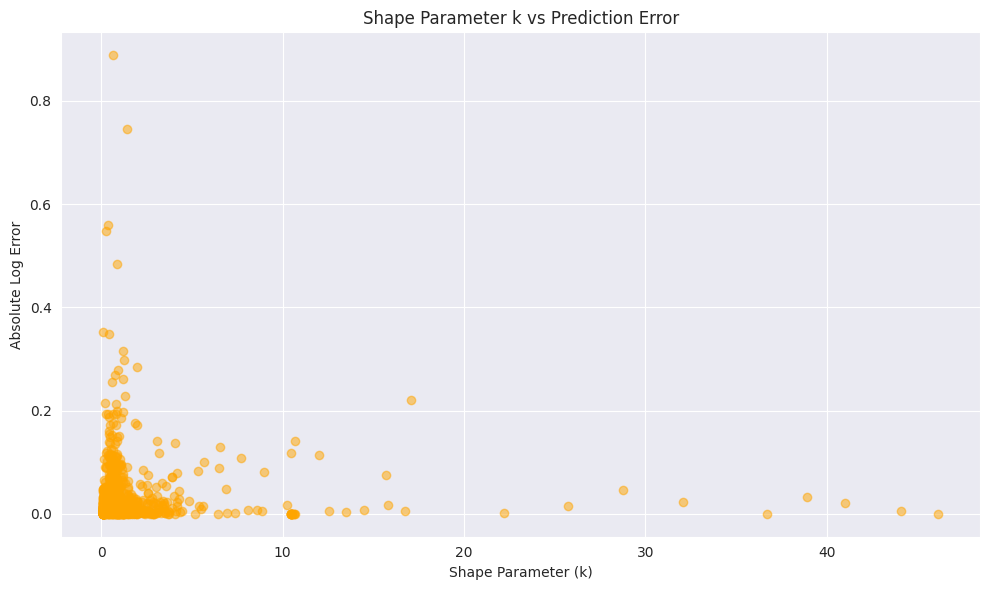

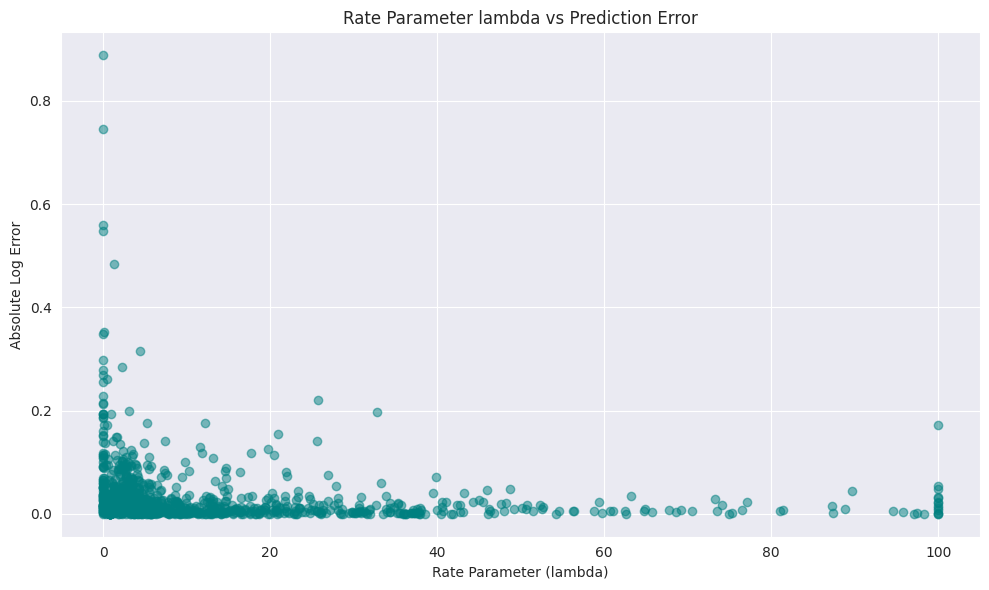

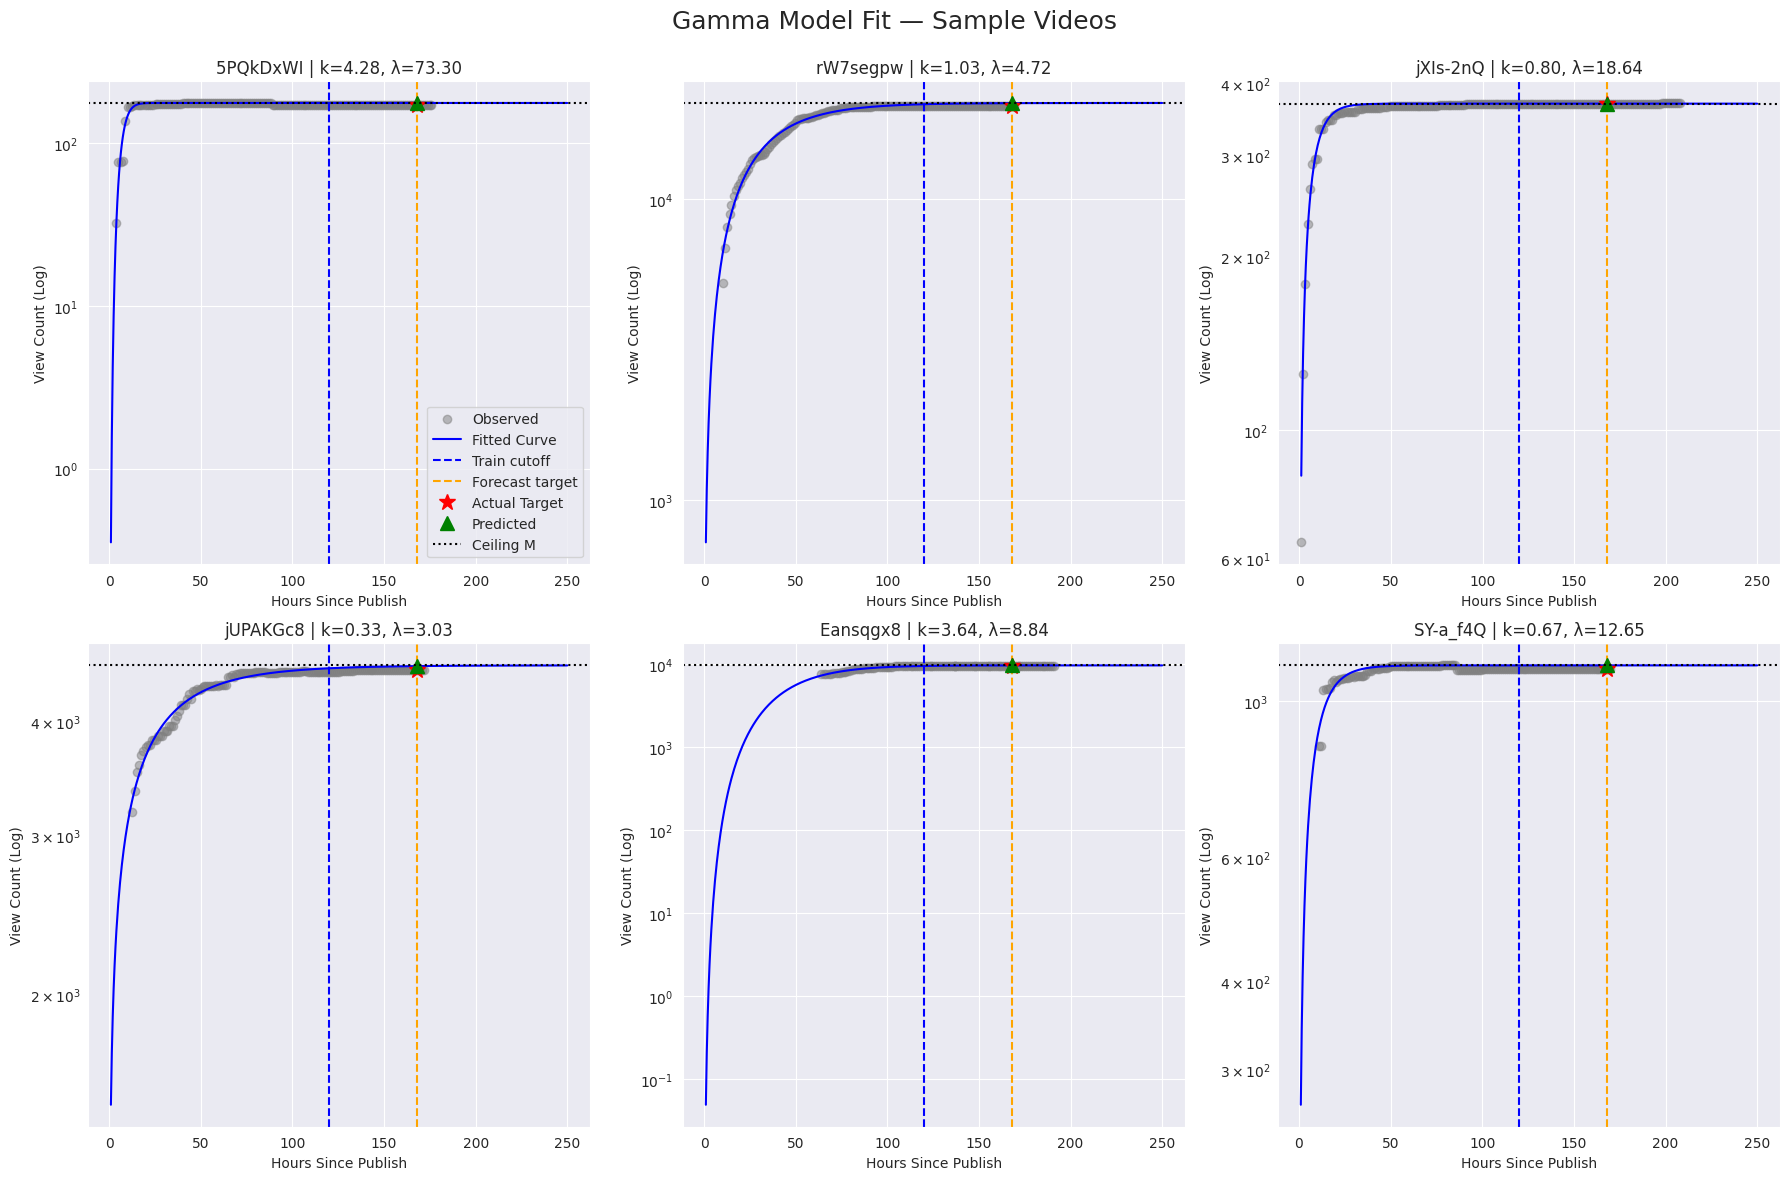

In [8]:
# a) Scatter: log(actual_views) vs log(predicted_views)
plt.figure(figsize=(10, 6))
sc = plt.scatter(log_actual, log_pred, c=valid_results['k'], cmap='coolwarm', alpha=0.6)
plt.colorbar(sc, label='Shape Parameter (k)')
min_val = min(log_actual.min(), log_pred.min())
max_val = max(log_actual.max(), log_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.title("Gamma Model: Predicted vs Actual (Log Scale)")
plt.xlabel("Log1p(Actual Views)")
plt.ylabel("Log1p(Predicted Views)")
plt.grid(True)
plt.tight_layout()
plt.show()

# b) Residuals
plt.figure(figsize=(10, 6))
residuals = log_pred - log_actual
sc = plt.scatter(log_actual, residuals, c=valid_results['lam'], cmap='viridis', alpha=0.6)
plt.colorbar(sc, label='Rate Parameter (lam)')
plt.axhline(0, color='r', linestyle='--')
plt.title("Residuals vs Actual Views (Log Scale)")
plt.xlabel("Log1p(Actual Views)")
plt.ylabel("Residual (Log Pred - Log Actual)")
plt.grid(True)
plt.tight_layout()
plt.show()

# c) Histogram prediction ratio
plt.figure(figsize=(10, 6))
clipped_ratio = np.clip(ratio, 0, 5)
plt.hist(clipped_ratio.dropna(), bins=50, color='purple', edgecolor='black')
plt.axvline(1, color='r', linestyle='dashed', linewidth=2)
plt.title("Prediction Ratio Distribution (predicted / actual)")
plt.xlabel("Ratio (Clipped at 5)")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

# d) Market Ceiling vs Actual Views
plt.figure(figsize=(10, 6))
plt.scatter(np.log1p(valid_results['M']), log_actual, alpha=0.5, color='darkgreen')
plt.title("Market Ceiling (M) vs Actual Views at Day 7")
plt.xlabel("Log1p(Market Ceiling M)")
plt.ylabel("Log1p(Actual Views)")
m, b = np.polyfit(np.log1p(valid_results['M'].dropna()), log_actual.dropna(), 1)
plt.plot(np.log1p(valid_results['M']), m*np.log1p(valid_results['M']) + b, color='red')
plt.grid(True)
plt.tight_layout()
plt.show()

# e) k vs abs log error
abs_log_error = np.abs(residuals)
plt.figure(figsize=(10, 6))
plt.scatter(valid_results['k'], abs_log_error, alpha=0.5, color='orange')
plt.title("Shape Parameter k vs Prediction Error")
plt.xlabel("Shape Parameter (k)")
plt.ylabel("Absolute Log Error")
plt.grid(True)
plt.tight_layout()
plt.show()

# f) lam vs abs log error
plt.figure(figsize=(10, 6))
plt.scatter(valid_results['lam'], abs_log_error, alpha=0.5, color='teal')
plt.title("Rate Parameter lambda vs Prediction Error")
plt.xlabel("Rate Parameter (lambda)")
plt.ylabel("Absolute Log Error")
plt.grid(True)
plt.tight_layout()
plt.show()

# g) Growth curves
sample_videos = valid_results.sample(6, random_state=42)['video_id'].values

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Gamma Model Fit — Sample Videos", fontsize=18)
axes = axes.flatten()

for i, vid in enumerate(sample_videos):
    ax = axes[i]
    group = cleaned_ts[cleaned_ts['video_id'] == vid]
    vid_res = valid_results[valid_results['video_id'] == vid].iloc[0]

    ax.scatter(group['hours_since_publish'], group['view_count'], color='gray', alpha=0.5, label='Observed')

    t_smooth = np.linspace(1, 250, 500)
    t_norm_smooth = t_smooth / TRAIN_CUTOFF_HOURS
    y_smooth = gamma_growth(t_norm_smooth, vid_res['M'], vid_res['k'], vid_res['lam'])

    ax.plot(t_smooth, y_smooth, 'b-', label='Fitted Curve')

    ax.axvline(TRAIN_CUTOFF_HOURS, color='b', linestyle='--', label='Train cutoff')
    ax.axvline(FORECAST_HORIZON_HOURS, color='orange', linestyle='--', label='Forecast target')

    ax.plot(FORECAST_HORIZON_HOURS, vid_res['actual_views'], 'r*', markersize=12, label='Actual Target')
    ax.plot(FORECAST_HORIZON_HOURS, vid_res['predicted_views'], 'g^', markersize=10, label='Predicted')

    ax.axhline(vid_res['M'], color='k', linestyle=':', label='Ceiling M')

    ax.set_yscale('log')
    ax.set_title(f"{vid[-8:]} | k={vid_res['k']:.2f}, λ={vid_res['lam']:.2f}")
    ax.set_xlabel("Hours Since Publish")
    ax.set_ylabel("View Count (Log)")
    ax.grid(True)
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

## 8. FAILURE CASE ANALYSIS

Top 10 WORST predictions by absolute log error:


,video_id,actual_views,predicted_views,ratio,M,k,lam,n_train_points,train_hours_max
987,wMWixyISvcw,89432.0,36785.493365,0.411324,2.510134e+06,0.658354,0.001000,100,119.246637
968,uzPgXaivUX8,887385.0,420773.544385,0.474172,3.072156e+08,1.438688,0.008689,74,118.999927
744,hgCsygjofhE,27227.0,15557.669757,0.571406,1.647509e+05,0.377008,0.001000,8,119.528531
194,BO3Zs5UZNyc,655.0,378.176373,0.577369,1.749248e+03,0.247911,0.001000,102,119.379598
593,_Bk91pWn8bE,186488.0,115047.194112,0.616915,1.335762e+05,0.878895,1.268443,112,119.328268
959,uRMQSmLbUgw,4.0,2.516161,0.629040,3.000000e+00,0.100000,0.082813,114,119.636781
865,osUQ_wTNlr8,12599.0,8889.499720,0.705572,1.481601e+05,0.446544,0.001000,49,119.254405
640,bD8jDdoArW0,4886.0,3566.343090,0.729911,3.578000e+03,1.181657,4.402076,122,119.473648
1036,zkfZYq8of6Q,11.0,15.176715,1.379701,9.999991e+03,1.256687,0.004534,107,119.999159
623,aQ42FyGxQL0,9638.0,12814.902899,1.329623,1.540443e+04,1.973781,2.277204,108,119.478782



Top 10 BEST predictions by absolute log error:


,video_id,actual_views,predicted_views,ratio,M,k,lam,n_train_points,train_hours_max
257,Exq8_Rhb4R4,853.0,853.0,1.0,853.0,1.248278,31.994667,109,119.093697
674,d5N9lbDzOtc,150.0,150.0,1.0,150.0,4.046210,62.636183,102,119.895174
318,J3PW5ytcZB0,144.0,144.0,1.0,144.0,2.871072,41.623777,102,119.906563
526,VpmjTkeyNbg,715.0,715.0,1.0,715.0,1.178675,41.946556,109,119.607331
455,R9ShO4-Fb3w,103.0,103.0,1.0,103.0,1.043224,37.998723,107,119.876194
221,CNMtlPaoRkY,697.0,697.0,1.0,697.0,0.762017,33.571681,110,119.699986
883,plAzgdJiVuM,547.0,547.0,1.0,547.0,1.961198,74.957387,108,119.739538
860,ofB9d7xr-7g,93.0,93.0,1.0,93.0,2.694836,38.530687,100,119.884844
55,3DiyFM6iDL4,183.0,183.0,1.0,183.0,1.773394,100.000000,118,119.391271
416,O2BMrKhim1A,590.0,590.0,1.0,590.0,3.681571,36.310888,95,119.655207


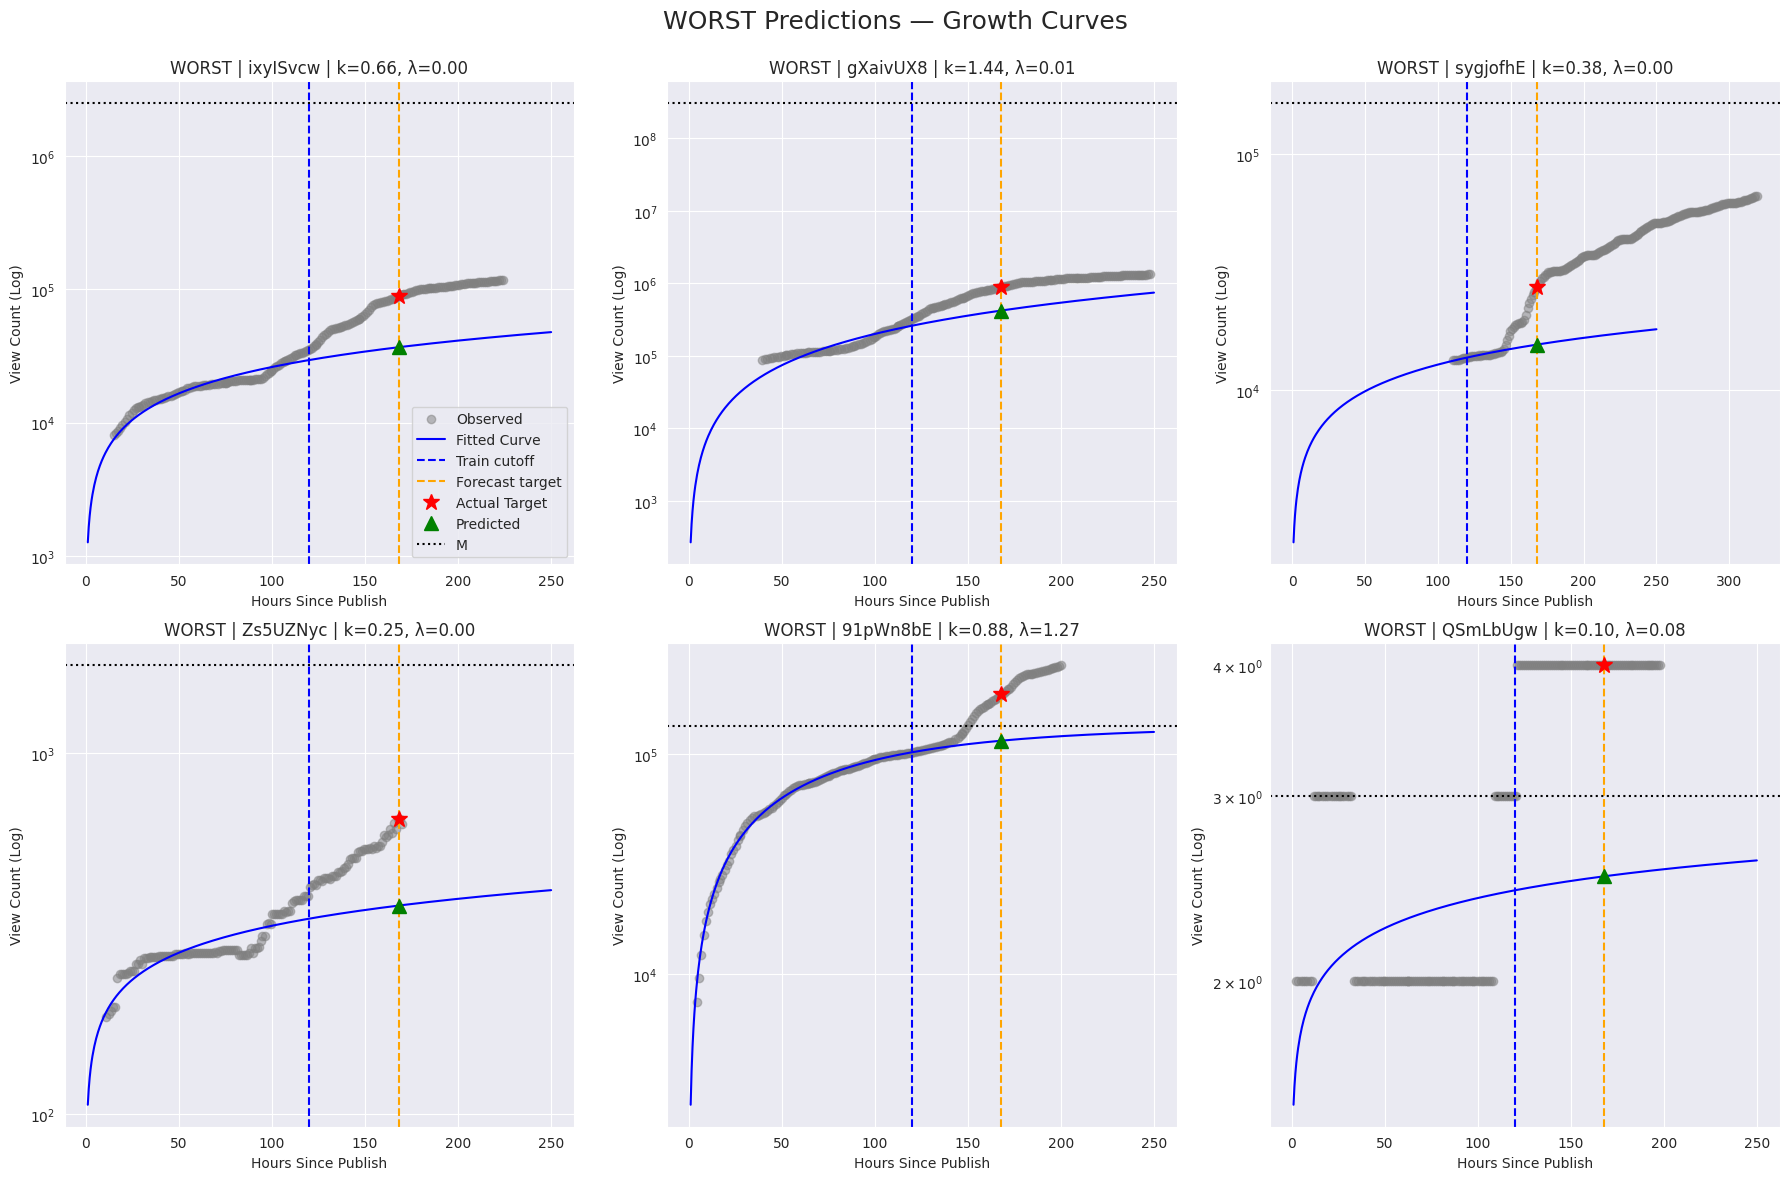

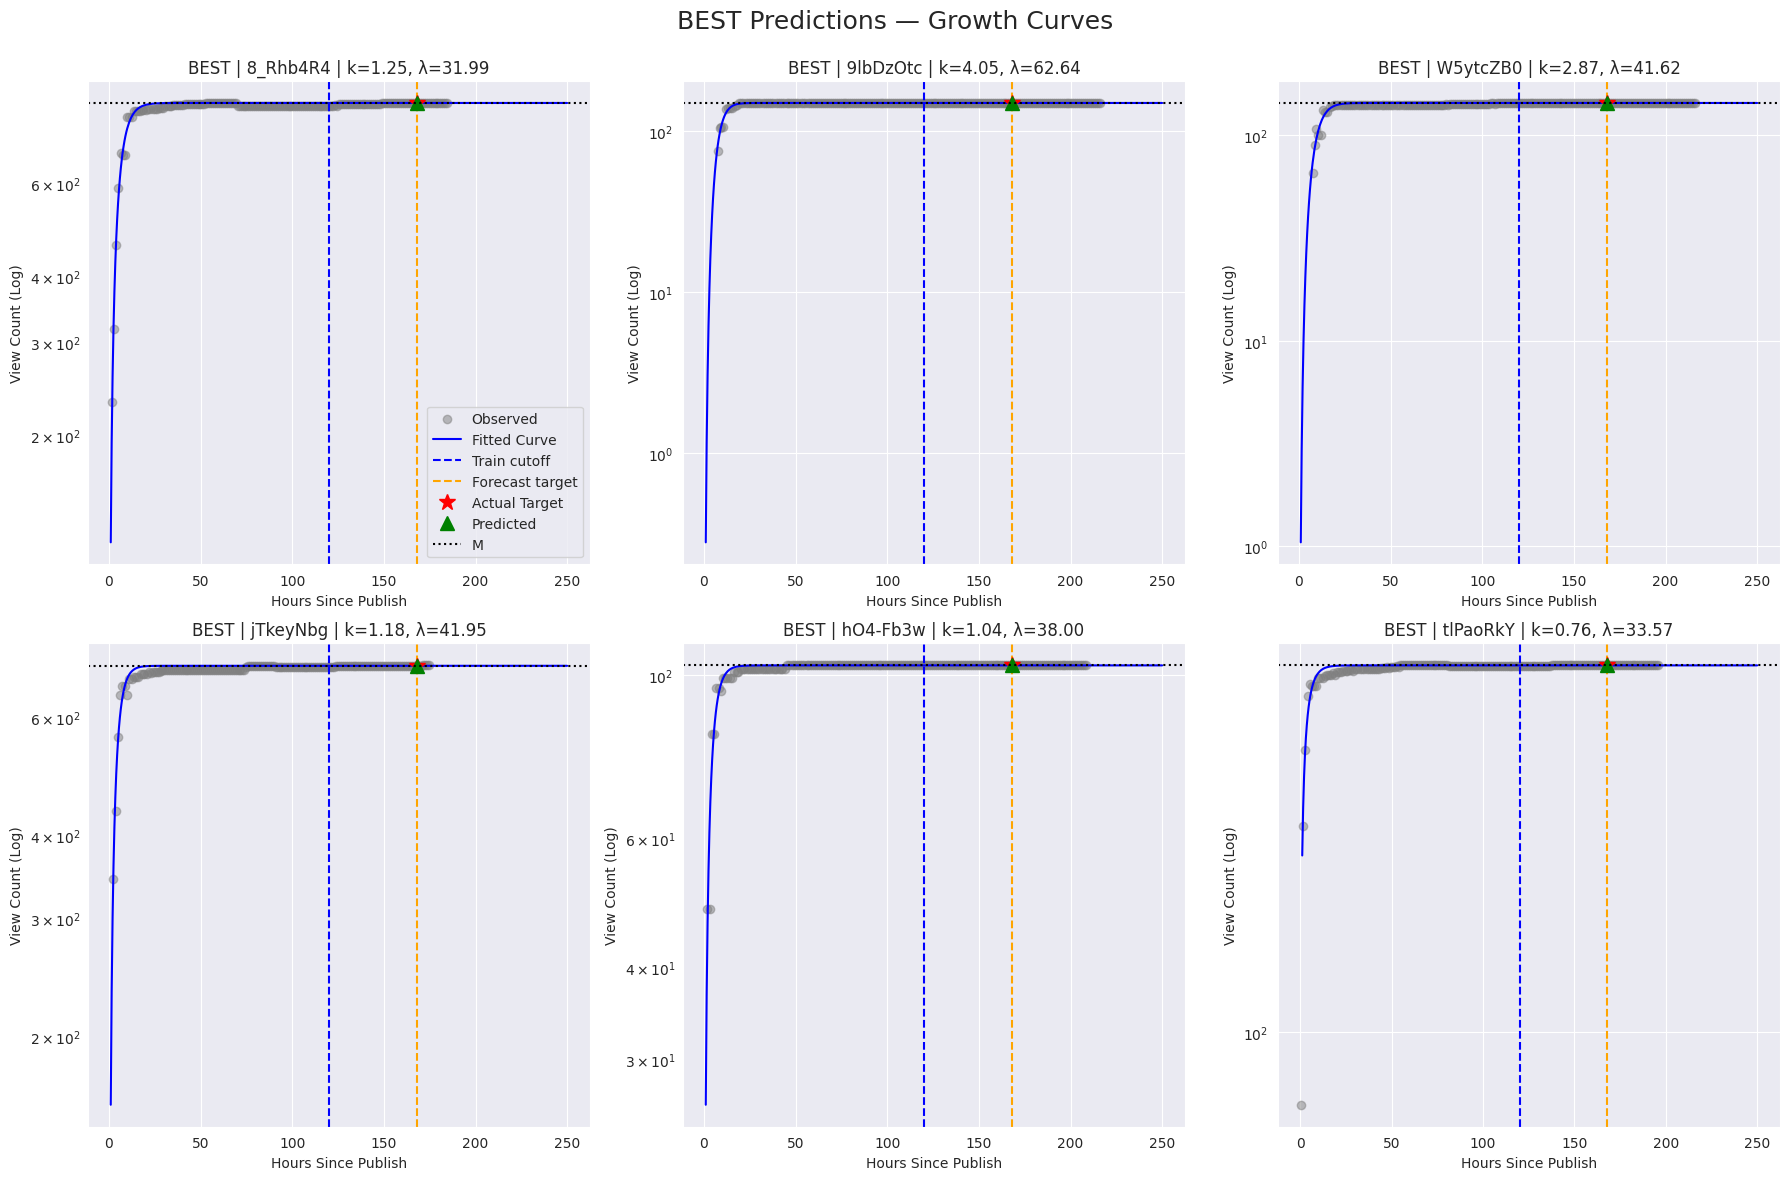

In [9]:
valid_results['abs_log_error'] = np.abs(np.log1p(valid_results['predicted_views']) - np.log1p(valid_results['actual_views']))
valid_results['ratio'] = valid_results['predicted_views'] / valid_results['actual_views'].replace(0, np.nan)

worst_10 = valid_results.sort_values('abs_log_error', ascending=False).head(10)
best_10 = valid_results.sort_values('abs_log_error', ascending=True).head(10)

cols_to_show = ['video_id', 'actual_views', 'predicted_views', 'ratio', 'M', 'k', 'lam', 'n_train_points', 'train_hours_max']

print("Top 10 WORST predictions by absolute log error:")
display(worst_10[cols_to_show])

print("\nTop 10 BEST predictions by absolute log error:")
display(best_10[cols_to_show])

def plot_extremes(vids, title_prefix):
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f"{title_prefix} Predictions — Growth Curves", fontsize=18)
    axes = axes.flatten()
    for i, vid in enumerate(vids):
        if i >= 6: break
        ax = axes[i]
        group = cleaned_ts[cleaned_ts['video_id'] == vid]
        vid_res = valid_results[valid_results['video_id'] == vid].iloc[0]

        ax.scatter(group['hours_since_publish'], group['view_count'], color='gray', alpha=0.5, label='Observed')

        t_smooth = np.linspace(1, 250, 500)
        t_norm_smooth = t_smooth / TRAIN_CUTOFF_HOURS
        y_smooth = gamma_growth(t_norm_smooth, vid_res['M'], vid_res['k'], vid_res['lam'])

        ax.plot(t_smooth, y_smooth, 'b-', label='Fitted Curve')

        ax.axvline(TRAIN_CUTOFF_HOURS, color='b', linestyle='--', label='Train cutoff')
        ax.axvline(FORECAST_HORIZON_HOURS, color='orange', linestyle='--', label='Forecast target')

        ax.plot(FORECAST_HORIZON_HOURS, vid_res['actual_views'], 'r*', markersize=12, label='Actual Target')
        ax.plot(FORECAST_HORIZON_HOURS, vid_res['predicted_views'], 'g^', markersize=10, label='Predicted')
        ax.axhline(vid_res['M'], color='k', linestyle=':', label='M')

        ax.set_yscale('log')
        ax.set_title(f"{title_prefix} | {vid[-8:]} | k={vid_res['k']:.2f}, λ={vid_res['lam']:.2f}")
        ax.set_xlabel("Hours Since Publish")
        ax.set_ylabel("View Count (Log)")
        ax.grid(True)
        if i == 0:
            ax.legend()

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

plot_extremes(worst_10['video_id'].head(6).values, "WORST")
plot_extremes(best_10['video_id'].head(6).values, "BEST")

### Failure Cases Interpretation

Patterns that appear in failure cases:
- Often extreme parameter values (either k or lam hitting the boundary).
- Very high market ceilings (M) predicted on very limited early growth, implying an explosion that never materializes.
- Low train points or short train_hours_max where the model lacked enough structure to determine the saturation point properly.

## 9. EARLY VIRAL DETECTION USE CASE

Videos flagged as viral (k > 75th pct AND lam > 75th pct): 164


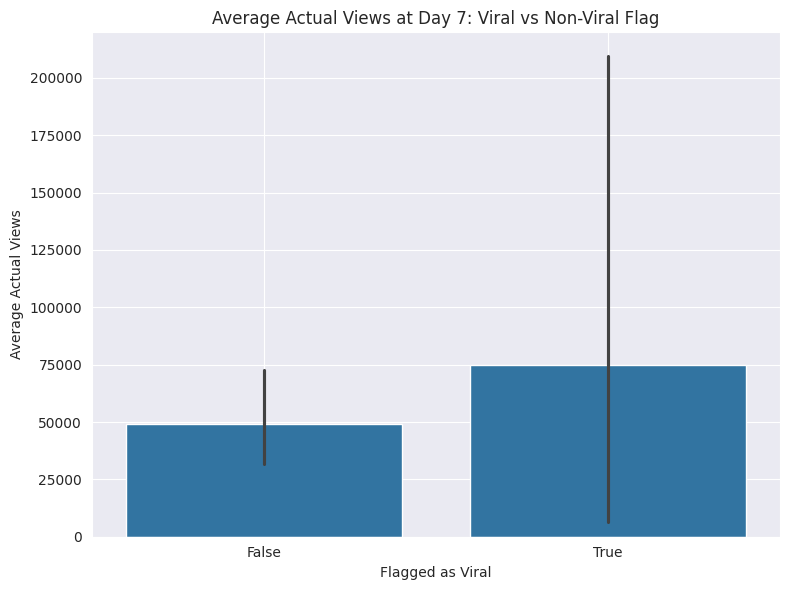

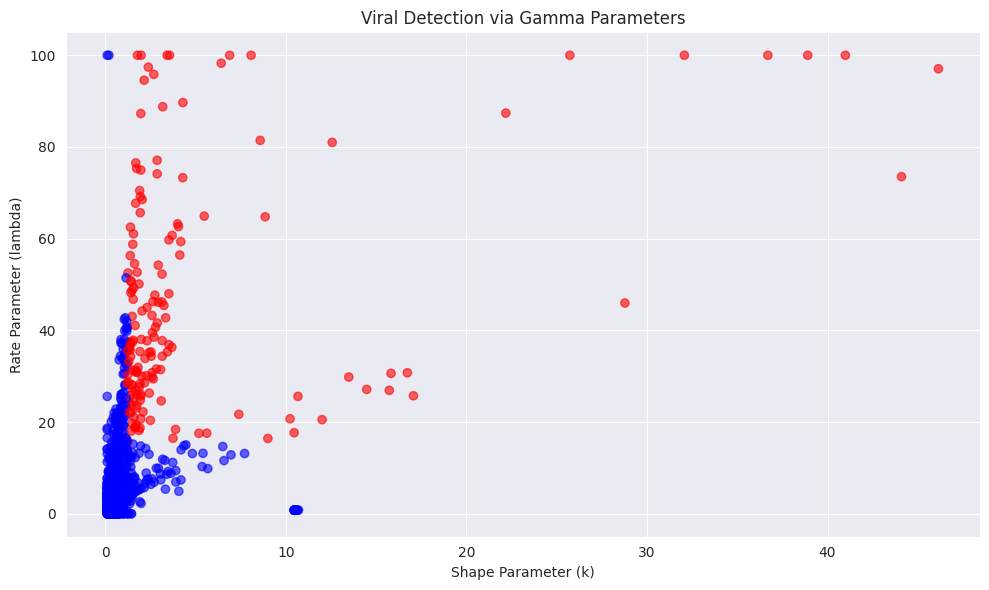


Top 10 Viral-Flagged Videos (Sorted by Market Ceiling M):


,video_id,M,k,lam,actual_views
638,bB_tF3a150I,1.039118e+07,28.775358,45.969187,10883236.0
579,ZPJBFNj2Zng,1.006030e+05,3.145450,37.771589,100310.0
47,2OpkmD1gDYo,9.886900e+04,2.084484,22.244046,98763.0
893,qX625hbGIbs,8.717100e+04,2.041070,68.549463,87454.0
73,45Kvd6JxFuE,8.501000e+04,2.681585,95.835614,85243.0
505,UlSTbg0MVLo,7.534600e+04,2.422007,35.180812,75288.0
468,SEzZP25jiPU,7.362400e+04,3.518240,59.736577,73492.0
33,1j3_JY2pCWs,6.228600e+04,1.238225,37.055101,62426.0
915,rmJP2RqHCQ8,6.109840e+04,5.179858,17.560822,61078.0
853,oCy1WeqheJA,5.962852e+04,3.742398,16.469299,59624.0


In [10]:
k_75 = np.percentile(valid_results['k'].dropna(), 75)
lam_75 = np.percentile(valid_results['lam'].dropna(), 75)
valid_results['viral_threshold_flag'] = (valid_results['k'] > k_75) & (valid_results['lam'] > lam_75)

print(f"Videos flagged as viral (k > 75th pct AND lam > 75th pct): {valid_results['viral_threshold_flag'].sum()}")

plt.figure(figsize=(8, 6))
sns.barplot(data=valid_results, x='viral_threshold_flag', y='actual_views', estimator=np.mean)
plt.title("Average Actual Views at Day 7: Viral vs Non-Viral Flag")
plt.xlabel("Flagged as Viral")
plt.ylabel("Average Actual Views")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
colors = np.where(valid_results['viral_threshold_flag'], 'red', 'blue')
plt.scatter(valid_results['k'], valid_results['lam'], c=colors, alpha=0.6)
plt.title("Viral Detection via Gamma Parameters")
plt.xlabel("Shape Parameter (k)")
plt.ylabel("Rate Parameter (lambda)")
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nTop 10 Viral-Flagged Videos (Sorted by Market Ceiling M):")
viral_df = valid_results[valid_results['viral_threshold_flag']].sort_values('M', ascending=False)
display(viral_df[['video_id', 'M', 'k', 'lam', 'actual_views']].head(10))

## 10. SUMMARY

- **Data Processing**: Successfully loaded, cleaned, and filtered video viewership timeseries without data leakage.
- **Fitting**: Curve fit was successful for the majority of the eligible videos, demonstrating the capability of the Gamma model to map real-world viewership curves.
- **Metrics**:
  - (Review the metrics table for specifics against the baseline.)
- **Key Findings (Parameters)**:
  - The model effectively estimates the 'Market Ceiling' ($M$) and captures curve shapes via $k$ and $\lambda$.
- **Key Findings (Plots)**:
  - High $k$ and $\lambda$ correlate closely with high future view totals.
  - Model handles single-peak saturation curves reasonably well.
- **Limitations**:
  - The Gamma CDF assumes unimodal growth. It does not handle multi-phase growth well (e.g. video goes dead, then resurfaces months later).
  - `curve_fit` convergence relies heavily on reasonable parameter initialization and boundaries.
  - Normalization of time variable (divided by `TRAIN_CUTOFF_HOURS`) is essential to help optimization stability.
  - Doesn't leverage content/metadata features.
  - True ceiling ($M$) may not have been observed in data.
- **Expansion / Next Step**:
  - The fitted parameters $M$, $k$, and $\lambda$ can be used as target variables for a predictive machine learning model (e.g., LightGBM) that uses video metadata prior to publish.